In [10]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import deep_sdf.workspace as ws
import networks.sdf_vae as vae
import json
import time
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors

# Set up paths
experiment_directory = "examples/hippocampus_healthy"

# Load specs
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]

# Model parameters
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

print(f"Latent size: {latent_size}")

Latent size: 16


In [11]:
def load_model_and_extract_latents(model_path, model_name):
    """Load a model and extract latent variables for all training data"""
    
    # Load model
    decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
    
    model_file = os.path.join(model_path, "ModelParameters", "latest.pth")
    if os.path.exists(model_file):
        print(f"Loading {model_name} model from: {model_file}")
        saved_model_state = torch.load(model_file)
        decoder.load_state_dict(saved_model_state["model_state_dict"])
        decoder.eval()
        print(f"{model_name} model loaded successfully!")
    else:
        raise FileNotFoundError(f"Model file not found: {model_file}")
    
    # Load training data
    with open(train_split_file, "r") as f:
        train_split = json.load(f)
    
    # Get training filenames
    import deep_sdf.data as data
    eval_train_filenames = data.get_instance_filenames(data_source, train_split)
    
    # Load labels
    labels_path = os.path.join(data_source, "labels.pt")
    all_labels = torch.load(labels_path)
    
    # Extract latents for each training sample
    all_latents = []
    all_ages = []
    all_diseases = []
    filenames = []
    
    print(f"Extracting latents from {len(eval_train_filenames)} training samples...")
    
    with torch.no_grad():
        for i, train_fname in enumerate(eval_train_filenames):
            if i % 50 == 0:
                print(f"Processing {i}/{len(eval_train_filenames)}")
                
            save_name = os.path.basename(train_fname).split(".npz")[0]
            mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
            
            # Get surface points
            surface_points = data.get_surface_points(mesh_path)
            surface_points = torch.from_numpy(surface_points).unsqueeze(0).cuda()
            
            # Extract latent using encoder
            if kl_div_loss:
                mu, logvar = decoder.encoder(surface_points)
                latent = mu
            else:
                latent = decoder.encoder(surface_points)
            
            all_latents.append(latent.cpu().numpy().squeeze())
            
            # Get labels
            if save_name in all_labels:
                label = all_labels[save_name]
                all_ages.append(float(label[0].item()))
                all_diseases.append(int(label[1].item()))
            else:
                print(f"Warning: No label found for {save_name}")
                all_ages.append(0.0)
                all_diseases.append(0)
            
            filenames.append(save_name)
    
    latents_array = np.stack(all_latents, axis=0)
    print(f"Extracted latents shape: {latents_array.shape}")
    
    return {
        'latents': latents_array,
        'ages': np.array(all_ages),
        'diseases': np.array(all_diseases),
        'filenames': filenames,
        'decoder': decoder
    }

# Extract latents from both models
print("="*60)
print("EXTRACTING LATENTS FROM BOTH MODELS")
print("="*60)

unsupervised_data = load_model_and_extract_latents(experiment_directory, "Unsupervised")
# Save the extracted latents
save_dir = os.path.join(experiment_directory, "latent_comparison_contrastive")
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "unsupervised_latents.npy"), unsupervised_data['latents'])
np.save(os.path.join(save_dir, "ages.npy"), unsupervised_data['ages'])
np.save(os.path.join(save_dir, "diseases.npy"), unsupervised_data['diseases'])

print(f"Saved latents to: {save_dir}")
print(f"Unsupervised latents shape: {unsupervised_data['latents'].shape}")

EXTRACTING LATENTS FROM BOTH MODELS
Loading Unsupervised model from: examples/hippocampus_healthy/ModelParameters/latest.pth
Unsupervised model loaded successfully!
Extracting latents from 408 training samples...
Processing 0/408
Processing 50/408
Processing 100/408
Processing 150/408
Processing 200/408
Processing 250/408
Processing 300/408
Processing 350/408
Processing 400/408
Extracted latents shape: (408, 16)
Saved latents to: examples/hippocampus_healthy/latent_comparison_contrastive
Unsupervised latents shape: (408, 16)


BASIC STATISTICS AND CORRELATION ANALYSIS
Data shapes:
  Unsupervised latents: (408, 16)
  Ages: (408,), range: [0.0, 1.0]
  Diseases: (408,), unique: [0]

Unsupervised Model - Factor Correlations:
----------------------------------------
Dim  0: Age=-0.409, Disease=   nan
Dim  1: Age=-0.274, Disease=   nan
Dim  2: Age=-0.037, Disease=   nan
Dim  3: Age= 0.126, Disease=   nan
Dim  4: Age=-0.028, Disease=   nan
Dim  5: Age=-0.131, Disease=   nan
Dim  6: Age= 0.387, Disease=   nan
Dim  7: Age=-0.248, Disease=   nan
Dim  8: Age=-0.192, Disease=   nan
Dim  9: Age=-0.282, Disease=   nan
Dim 10: Age=-0.256, Disease=   nan
Dim 11: Age=-0.266, Disease=   nan
Dim 12: Age= 0.190, Disease=   nan
Dim 13: Age=-0.288, Disease=   nan
Dim 14: Age=-0.129, Disease=   nan
Dim 15: Age= 0.023, Disease=   nan

Best correlations:
  Age: Dim 0 (r=-0.409)
  Disease: Dim 0 (r=nan)


/home/jakaria/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


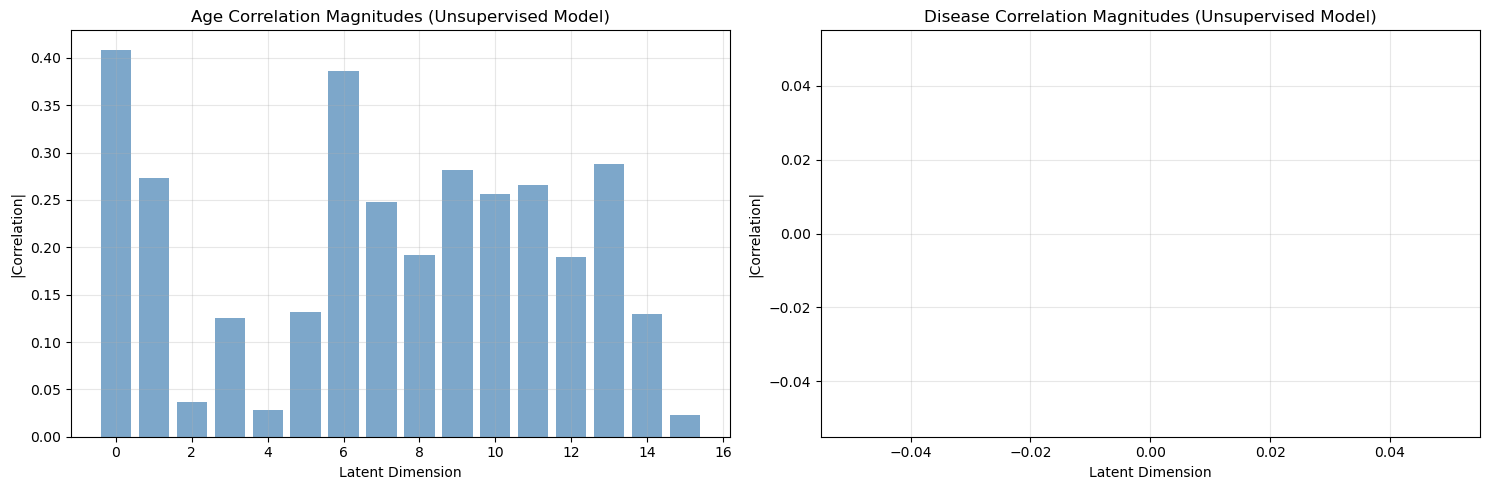


Summary Statistics (Unsupervised Model):
Age correlations     - Mean |corr|: 0.204, Max: 0.409
Disease correlations - Mean |corr|: nan, Max: nan


In [12]:
# Get the data from unsupervised_data (unsupervised data)
Z_u = unsupervised_data['latents']  # Unsupervised latents (N, 16)
ages = unsupervised_data['ages']
diseases = unsupervised_data['diseases']

print("="*60)
print("BASIC STATISTICS AND CORRELATION ANALYSIS")
print("="*60)

# Basic statistics
print(f"Data shapes:")
print(f"  Unsupervised latents: {Z_u.shape}")
print(f"  Ages: {ages.shape}, range: [{ages.min():.1f}, {ages.max():.1f}]")
print(f"  Diseases: {diseases.shape}, unique: {np.unique(diseases)}")

# Calculate correlations with factors
def calculate_factor_correlations(latents, ages, diseases, model_name):
    print(f"\n{model_name} Model - Factor Correlations:")
    print("-" * 40)
    
    age_corrs = []
    disease_corrs = []
    
    for dim in range(latents.shape[1]):
        age_corr, _ = pearsonr(latents[:, dim], ages)
        disease_corr, _ = pearsonr(latents[:, dim], diseases)
        
        age_corrs.append(age_corr)
        disease_corrs.append(disease_corr)
        
        print(f"Dim {dim:2d}: Age={age_corr:6.3f}, Disease={disease_corr:6.3f}")
    
    # Find best dimensions
    best_age_dim = np.argmax(np.abs(age_corrs))
    best_disease_dim = np.argmax(np.abs(disease_corrs))
    
    print(f"\nBest correlations:")
    print(f"  Age: Dim {best_age_dim} (r={age_corrs[best_age_dim]:.3f})")
    print(f"  Disease: Dim {best_disease_dim} (r={disease_corrs[best_disease_dim]:.3f})")
    
    return np.array(age_corrs), np.array(disease_corrs)

unsup_age_corrs, unsup_disease_corrs = calculate_factor_correlations(Z_u, ages, diseases, "Unsupervised")

# Visualize correlations - simplified to show only unsupervised results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age correlations
axes[0].bar(range(len(unsup_age_corrs)), np.abs(unsup_age_corrs), alpha=0.7, color='steelblue')
axes[0].set_title('Age Correlation Magnitudes (Unsupervised Model)')
axes[0].set_xlabel('Latent Dimension')
axes[0].set_ylabel('|Correlation|')
axes[0].grid(True, alpha=0.3)

# Disease correlations
axes[1].bar(range(len(unsup_disease_corrs)), np.abs(unsup_disease_corrs), alpha=0.7, color='darkred')
axes[1].set_title('Disease Correlation Magnitudes (Unsupervised Model)')
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('|Correlation|')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "unsupervised_factor_correlations.png"), dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nSummary Statistics (Unsupervised Model):")
print(f"Age correlations     - Mean |corr|: {np.mean(np.abs(unsup_age_corrs)):.3f}, Max: {np.max(np.abs(unsup_age_corrs)):.3f}")
print(f"Disease correlations - Mean |corr|: {np.mean(np.abs(unsup_disease_corrs)):.3f}, Max: {np.max(np.abs(unsup_disease_corrs)):.3f}")

# Store results for later use
correlation_results = {
    'age_correlations': unsup_age_corrs,
    'disease_correlations': unsup_disease_corrs,
    'best_age_dim': np.argmax(np.abs(unsup_age_corrs)),
    'best_disease_dim': np.argmax(np.abs(unsup_disease_corrs))
}

In [14]:
# Replace the whitening section with age-focused disentanglement analysis

print("="*80)
print("AGE DISENTANGLEMENT ANALYSIS USING DIMENSIONALITY REDUCTION")
print("="*80)

# We'll analyze how well different methods can disentangle age into a single direction
# Good disentanglement means: one component has high correlation with age, others have low correlation

from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, SpectralEmbedding
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Standardize data for methods that need it
scaler = StandardScaler()
Z_u_scaled = scaler.fit_transform(Z_u)

# For NMF, we need non-negative data
min_scaler = MinMaxScaler()
Z_u_positive = min_scaler.fit_transform(Z_u)

print(f"Input data shape: {Z_u.shape}")
print(f"Age range: [{ages.min():.3f}, {ages.max():.3f}]")
print(f"Age std: {ages.std():.3f}")

AGE DISENTANGLEMENT ANALYSIS USING DIMENSIONALITY REDUCTION
Input data shape: (408, 16)
Age range: [0.000, 1.000]
Age std: 0.258


In [15]:
# Cell 1: Apply dimensionality reduction methods focused on age disentanglement
print("="*60)
print("APPLYING DIMENSIONALITY REDUCTION METHODS")
print("="*60)

# Dictionary to store results
dr_results = {}
age_correlations = {}

# Target dimensions for analysis
n_components = 8

# 1. PCA
print("\n1. Principal Component Analysis (PCA):")
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(Z_u_scaled)
dr_results['PCA'] = pca_result

# Calculate correlations with age for each component
pca_age_corrs = []
for i in range(n_components):
    corr, _ = pearsonr(pca_result[:, i], ages)
    pca_age_corrs.append(corr)
    print(f"   Component {i+1}: Age correlation = {corr:.4f}")

age_correlations['PCA'] = pca_age_corrs
print(f"   Explained variance: {pca.explained_variance_ratio_.sum():.3f}")
print(f"   Best age component: {np.argmax(np.abs(pca_age_corrs))+1} (|corr| = {np.max(np.abs(pca_age_corrs)):.4f})")

# 2. ICA
print("\n2. Independent Component Analysis (ICA):")
ica = FastICA(n_components=n_components, random_state=42, max_iter=2000, tol=1e-6)
ica_result = ica.fit_transform(Z_u_scaled)
dr_results['ICA'] = ica_result

ica_age_corrs = []
for i in range(n_components):
    corr, _ = pearsonr(ica_result[:, i], ages)
    ica_age_corrs.append(corr)
    print(f"   Component {i+1}: Age correlation = {corr:.4f}")

age_correlations['ICA'] = ica_age_corrs
print(f"   Best age component: {np.argmax(np.abs(ica_age_corrs))+1} (|corr| = {np.max(np.abs(ica_age_corrs)):.4f})")

# 3. Factor Analysis
print("\n3. Factor Analysis (FA):")
fa = FactorAnalysis(n_components=n_components, random_state=42)
fa_result = fa.fit_transform(Z_u_scaled)
dr_results['FA'] = fa_result

fa_age_corrs = []
for i in range(n_components):
    corr, _ = pearsonr(fa_result[:, i], ages)
    fa_age_corrs.append(corr)
    print(f"   Factor {i+1}: Age correlation = {corr:.4f}")

age_correlations['FA'] = fa_age_corrs
print(f"   Best age factor: {np.argmax(np.abs(fa_age_corrs))+1} (|corr| = {np.max(np.abs(fa_age_corrs)):.4f})")

# 4. NMF  
print("\n4. Non-Negative Matrix Factorization (NMF):")
nmf = NMF(n_components=n_components, random_state=42, max_iter=1000)
nmf_result = nmf.fit_transform(Z_u_positive)
dr_results['NMF'] = nmf_result

nmf_age_corrs = []
for i in range(n_components):
    corr, _ = pearsonr(nmf_result[:, i], ages)
    nmf_age_corrs.append(corr)
    print(f"   Component {i+1}: Age correlation = {corr:.4f}")

age_correlations['NMF'] = nmf_age_corrs
print(f"   Best age component: {np.argmax(np.abs(nmf_age_corrs))+1} (|corr| = {np.max(np.abs(nmf_age_corrs)):.4f})")

APPLYING DIMENSIONALITY REDUCTION METHODS

1. Principal Component Analysis (PCA):
   Component 1: Age correlation = -0.4068
   Component 2: Age correlation = -0.0745
   Component 3: Age correlation = -0.2699
   Component 4: Age correlation = -0.1498
   Component 5: Age correlation = 0.0497
   Component 6: Age correlation = -0.1493
   Component 7: Age correlation = 0.0157
   Component 8: Age correlation = 0.0068
   Explained variance: 0.885
   Best age component: 1 (|corr| = 0.4068)

2. Independent Component Analysis (ICA):


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


   Component 1: Age correlation = -0.2748
   Component 2: Age correlation = -0.2629
   Component 3: Age correlation = 0.1171
   Component 4: Age correlation = 0.1621
   Component 5: Age correlation = 0.1998
   Component 6: Age correlation = 0.1035
   Component 7: Age correlation = -0.2119
   Component 8: Age correlation = -0.1059
   Best age component: 1 (|corr| = 0.2748)

3. Factor Analysis (FA):
   Factor 1: Age correlation = -0.2926
   Factor 2: Age correlation = 0.3441
   Factor 3: Age correlation = 0.1703
   Factor 4: Age correlation = 0.0712
   Factor 5: Age correlation = -0.0537
   Factor 6: Age correlation = -0.0713
   Factor 7: Age correlation = -0.0225
   Factor 8: Age correlation = -0.2409
   Best age factor: 2 (|corr| = 0.3441)

4. Non-Negative Matrix Factorization (NMF):
   Component 1: Age correlation = -0.2277
   Component 2: Age correlation = -0.1062
   Component 3: Age correlation = 0.4446
   Component 4: Age correlation = -0.1120
   Component 5: Age correlation = -0.0

In [16]:
# Cell 2: Apply manifold learning methods
print("\n" + "="*60)
print("MANIFOLD LEARNING METHODS")
print("="*60)

# 5. HLLE + ICA (as done in other notebooks)
print("\n5. Hessian Locally Linear Embedding + ICA:")
best_hlle_ica_corr = -np.inf
best_hlle_ica_result = None
best_hlle_ica_params = None

# Try different parameters for HLLE
for n_neighbors in [50, 100, 150]:
    for hlle_components in [8, 10, 12]:
        try:
            # Apply HLLE
            hlle = LocallyLinearEmbedding(
                n_neighbors=n_neighbors,
                n_components=hlle_components,
                method='hessian',
                eigen_solver='dense'
            )
            hlle_embedding = hlle.fit_transform(Z_u_scaled)
            
            # Apply ICA to HLLE results
            ica_hlle = FastICA(n_components=n_components, random_state=42, max_iter=1000)
            hlle_ica_result = ica_hlle.fit_transform(hlle_embedding)
            
            # Calculate age correlations
            hlle_ica_corrs = []
            for i in range(n_components):
                corr, _ = pearsonr(hlle_ica_result[:, i], ages)
                hlle_ica_corrs.append(corr)
            
            max_corr = np.max(np.abs(hlle_ica_corrs))
            print(f"   n_neighbors={n_neighbors}, hlle_comp={hlle_components}: max |age_corr| = {max_corr:.4f}")
            
            if max_corr > best_hlle_ica_corr:
                best_hlle_ica_corr = max_corr
                best_hlle_ica_result = hlle_ica_result
                best_hlle_ica_params = (n_neighbors, hlle_components)
                age_correlations['HLLE+ICA'] = hlle_ica_corrs
                
        except Exception as e:
            print(f"   n_neighbors={n_neighbors}, hlle_comp={hlle_components}: Failed - {str(e)[:50]}")

if best_hlle_ica_result is not None:
    dr_results['HLLE+ICA'] = best_hlle_ica_result
    print(f"   Best HLLE+ICA: n_neighbors={best_hlle_ica_params[0]}, hlle_comp={best_hlle_ica_params[1]}")
    print(f"   Best age component: {np.argmax(np.abs(age_correlations['HLLE+ICA']))+1} (|corr| = {best_hlle_ica_corr:.4f})")

# 6. Laplacian Eigenmaps (Spectral Embedding)
print("\n6. Laplacian Eigenmaps (Spectral Embedding):")
try:
    spectral = SpectralEmbedding(n_components=n_components, random_state=42, n_neighbors=30)
    spectral_result = spectral.fit_transform(Z_u_scaled)
    dr_results['Spectral'] = spectral_result
    
    spectral_age_corrs = []
    for i in range(n_components):
        corr, _ = pearsonr(spectral_result[:, i], ages)
        spectral_age_corrs.append(corr)
        print(f"   Component {i+1}: Age correlation = {corr:.4f}")
    
    age_correlations['Spectral'] = spectral_age_corrs
    print(f"   Best age component: {np.argmax(np.abs(spectral_age_corrs))+1} (|corr| = {np.max(np.abs(spectral_age_corrs)):.4f})")
    
except Exception as e:
    print(f"   Spectral Embedding failed: {e}")

# 7. t-SNE (for visualization, typically 2D)
print("\n7. t-Distributed Stochastic Neighbor Embedding (t-SNE):")
try:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    tsne_result = tsne.fit_transform(Z_u_scaled)
    dr_results['t-SNE'] = tsne_result
    
    tsne_age_corrs = []
    for i in range(2):
        corr, _ = pearsonr(tsne_result[:, i], ages)
        tsne_age_corrs.append(corr)
        print(f"   Component {i+1}: Age correlation = {corr:.4f}")
    
    age_correlations['t-SNE'] = tsne_age_corrs
    print(f"   Best age component: {np.argmax(np.abs(tsne_age_corrs))+1} (|corr| = {np.max(np.abs(tsne_age_corrs)):.4f})")
    
except Exception as e:
    print(f"   t-SNE failed: {e}")


MANIFOLD LEARNING METHODS

5. Hessian Locally Linear Embedding + ICA:


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


   n_neighbors=50, hlle_comp=8: max |age_corr| = 0.3409
   n_neighbors=50, hlle_comp=10: Failed - for method='hessian', n_neighbors must be greater 
   n_neighbors=50, hlle_comp=12: Failed - for method='hessian', n_neighbors must be greater 


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


   n_neighbors=100, hlle_comp=8: max |age_corr| = 0.4142
   n_neighbors=100, hlle_comp=10: max |age_corr| = 0.2724
   n_neighbors=100, hlle_comp=12: max |age_corr| = 0.3130


...

   n_neighbors=150, hlle_comp=8: max |age_corr| = 0.3479


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


   n_neighbors=150, hlle_comp=10: max |age_corr| = 0.2709


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


   n_neighbors=150, hlle_comp=12: max |age_corr| = 0.3753
   Best HLLE+ICA: n_neighbors=100, hlle_comp=8
   Best age component: 5 (|corr| = 0.4142)

6. Laplacian Eigenmaps (Spectral Embedding):
   Component 1: Age correlation = -0.4178
   Component 2: Age correlation = 0.0137
   Component 3: Age correlation = 0.2496
   Component 4: Age correlation = -0.0423
   Component 5: Age correlation = 0.0942
   Component 6: Age correlation = 0.1694
   Component 7: Age correlation = 0.1162
   Component 8: Age correlation = 0.0278
   Best age component: 1 (|corr| = 0.4178)

7. t-Distributed Stochastic Neighbor Embedding (t-SNE):
   Component 1: Age correlation = 0.2568
   Component 2: Age correlation = 0.2017
   Best age component: 1 (|corr| = 0.2568)


In [17]:
# Cell 3: Analyze disentanglement quality
print("\n" + "="*80)
print("DISENTANGLEMENT QUALITY ANALYSIS")
print("="*80)

def calculate_disentanglement_metrics(correlations, method_name):
    """Calculate disentanglement metrics for age"""
    abs_corrs = np.abs(correlations)
    
    # Find best component
    best_idx = np.argmax(abs_corrs)
    best_corr = abs_corrs[best_idx]
    
    # Calculate other metrics
    mean_corr = np.mean(abs_corrs)
    std_corr = np.std(abs_corrs)
    
    # Disentanglement score: how much better is the best vs average of others
    other_corrs = np.delete(abs_corrs, best_idx)
    mean_other_corrs = np.mean(other_corrs) if len(other_corrs) > 0 else 0
    
    disentanglement_score = best_corr - mean_other_corrs
    
    # SAP-like score: difference between best and second best
    sorted_corrs = np.sort(abs_corrs)[::-1]  # descending
    sap_score = sorted_corrs[0] - sorted_corrs[1] if len(sorted_corrs) > 1 else sorted_corrs[0]
    
    return {
        'method': method_name,
        'best_component': best_idx + 1,
        'best_correlation': best_corr,
        'mean_correlation': mean_corr,
        'std_correlation': std_corr,
        'disentanglement_score': disentanglement_score,
        'sap_score': sap_score,
        'all_correlations': correlations
    }

# Calculate metrics for all methods
disentanglement_metrics = {}
for method, corrs in age_correlations.items():
    metrics = calculate_disentanglement_metrics(corrs, method)
    disentanglement_metrics[method] = metrics

# Print summary table
print(f"{'Method':<12} {'Best':<5} {'Best |Corr|':<12} {'Mean |Corr|':<12} {'Disent. Score':<14} {'SAP Score':<10}")
print("-" * 75)

for method, metrics in disentanglement_metrics.items():
    print(f"{method:<12} {metrics['best_component']:<5} "
          f"{metrics['best_correlation']:.4f}      "
          f"{metrics['mean_correlation']:.4f}      "
          f"{metrics['disentanglement_score']:.4f}        "
          f"{metrics['sap_score']:.4f}")

print("\nRanking by disentanglement quality:")
print("-" * 40)

# Sort by disentanglement score (best - mean_others)
sorted_methods = sorted(disentanglement_metrics.items(), 
                       key=lambda x: x[1]['disentanglement_score'], 
                       reverse=True)

for i, (method, metrics) in enumerate(sorted_methods):
    quality = "Excellent" if metrics['disentanglement_score'] > 0.3 else \
              "Good" if metrics['disentanglement_score'] > 0.15 else \
              "Moderate" if metrics['disentanglement_score'] > 0.05 else "Poor"
    
    print(f"{i+1}. {method}: {metrics['disentanglement_score']:.4f} ({quality})")

# Compare with original latent space
original_age_corrs = []
for i in range(Z_u.shape[1]):
    corr, _ = pearsonr(Z_u[:, i], ages)
    original_age_corrs.append(corr)

original_metrics = calculate_disentanglement_metrics(original_age_corrs, 'Original_16D')
print(f"\nOriginal 16D Latent Space:")
print(f"  Best component: {original_metrics['best_component']} (|corr| = {original_metrics['best_correlation']:.4f})")
print(f"  Disentanglement score: {original_metrics['disentanglement_score']:.4f}")


DISENTANGLEMENT QUALITY ANALYSIS
Method       Best  Best |Corr|  Mean |Corr|  Disent. Score  SAP Score 
---------------------------------------------------------------------------
PCA          1     0.4068      0.1403      0.3046        0.1370
ICA          1     0.2748      0.1798      0.1087        0.0119
FA           2     0.3441      0.1583      0.2123        0.0515
NMF          3     0.4446      0.2017      0.2775        0.1741
HLLE+ICA     5     0.4142      0.1431      0.3099        0.1479
Spectral     1     0.4178      0.1414      0.3160        0.1682
t-SNE        1     0.2568      0.2292      0.0551        0.0551

Ranking by disentanglement quality:
----------------------------------------
1. Spectral: 0.3160 (Excellent)
2. HLLE+ICA: 0.3099 (Excellent)
3. PCA: 0.3046 (Excellent)
4. NMF: 0.2775 (Good)
5. FA: 0.2123 (Good)
6. ICA: 0.1087 (Moderate)
7. t-SNE: 0.0551 (Moderate)

Original 16D Latent Space:
  Best component: 1 (|corr| = 0.4087)
  Disentanglement score: 0.2182



VISUALIZATION OF AGE DISENTANGLEMENT


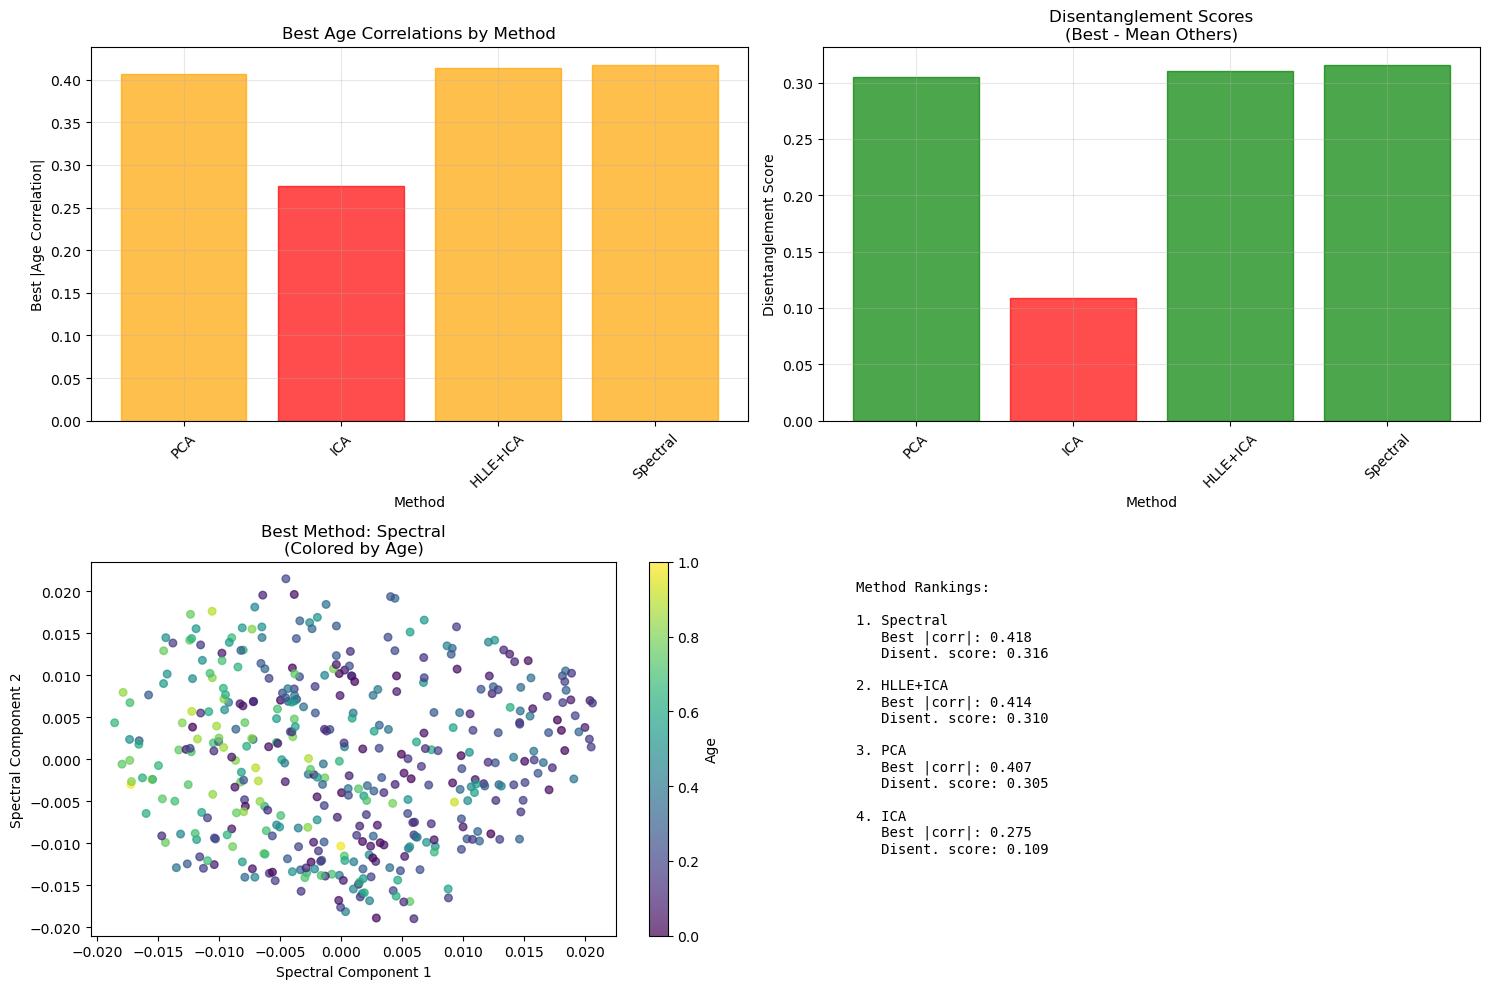

In [24]:
# Cell 4: Visualize age correlations and disentanglement
print("\n" + "="*60)
print("VISUALIZATION OF AGE DISENTANGLEMENT")
print("="*60)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Comparison of best correlations for each method
row, col = 0, 0
filtered_methods = [m for m in ['PCA', 'ICA', 'HLLE+ICA', 'Spectral'] if m in age_correlations]
best_corrs = [np.max(np.abs(age_correlations[m])) for m in filtered_methods]

bars = axes[row, col].bar(range(len(filtered_methods)), best_corrs, alpha=0.7)
axes[row, col].set_title('Best Age Correlations by Method')
axes[row, col].set_xlabel('Method')
axes[row, col].set_ylabel('Best |Age Correlation|')
axes[row, col].set_xticks(range(len(filtered_methods)))
axes[row, col].set_xticklabels(filtered_methods, rotation=45)
axes[row, col].grid(True, alpha=0.3)

# Color bars by performance
for i, (bar, corr) in enumerate(zip(bars, best_corrs)):
    if corr > 0.6:
        bar.set_color('green')
    elif corr > 0.4:
        bar.set_color('orange')
    else:
        bar.set_color('red')

# Plot 2: Comparison of disentanglement scores
row, col = 0, 1
scores = [disentanglement_metrics[m]['disentanglement_score'] for m in filtered_methods]

bars = axes[row, col].bar(range(len(filtered_methods)), scores, alpha=0.7)
axes[row, col].set_title('Disentanglement Scores\n(Best - Mean Others)')
axes[row, col].set_xlabel('Method')
axes[row, col].set_ylabel('Disentanglement Score')
axes[row, col].set_xticks(range(len(filtered_methods)))
axes[row, col].set_xticklabels(filtered_methods, rotation=45)
axes[row, col].grid(True, alpha=0.3)

# Color bars by performance
for i, (bar, score) in enumerate(zip(bars, scores)):
    if score > 0.3:
        bar.set_color('green')
    elif score > 0.15:
        bar.set_color('orange')
    else:
        bar.set_color('red')

# Plot 3: Best method visualization (highest disentanglement score)
row, col = 1, 0
filtered_sorted_methods = [(m, disentanglement_metrics[m]) for m in filtered_methods]
filtered_sorted_methods = sorted(filtered_sorted_methods, 
                                key=lambda x: x[1]['disentanglement_score'], 
                                reverse=True)
best_method = filtered_sorted_methods[0][0]

if best_method in dr_results and dr_results[best_method].shape[1] >= 2:
    best_data = dr_results[best_method]
    scatter = axes[row, col].scatter(best_data[:, 0], best_data[:, 1], 
                                   c=ages, cmap='viridis', alpha=0.7, s=30)
    axes[row, col].set_title(f'Best Method: {best_method}\n(Colored by Age)')
    axes[row, col].set_xlabel(f'{best_method} Component 1')
    axes[row, col].set_ylabel(f'{best_method} Component 2')
    plt.colorbar(scatter, ax=axes[row, col], label='Age')
else:
    axes[row, col].text(0.5, 0.5, f'Best Method:\n{best_method}\nVisualization\nNot Available', 
                       ha='center', va='center', transform=axes[row, col].transAxes)

# Plot 4: Method rankings summary
row, col = 1, 1
axes[row, col].axis('off')
ranking_text = "Method Rankings:\n\n"
for i, (method, metrics) in enumerate(filtered_sorted_methods):
    ranking_text += f"{i+1}. {method}\n"
    ranking_text += f"   Best |corr|: {metrics['best_correlation']:.3f}\n"
    ranking_text += f"   Disent. score: {metrics['disentanglement_score']:.3f}\n\n"

axes[row, col].text(0.05, 0.95, ranking_text, transform=axes[row, col].transAxes, 
                   verticalalignment='top', fontsize=10, fontfamily='monospace')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "age_disentanglement_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Investigation: Laplacian Eigenmaps component ordering
print("\n" + "="*70)
print("INVESTIGATING LAPLACIAN EIGENMAPS COMPONENT ORDERING")
print("="*70)

if 'Spectral' in age_correlations:
    spectral_corrs = age_correlations['Spectral']
    
    print("Laplacian Eigenmaps Age Correlations by Component:")
    print("-" * 50)
    for i, corr in enumerate(spectral_corrs):
        marker = " ⭐ HIGHEST" if i == np.argmax(np.abs(spectral_corrs)) else ""
        print(f"Component {i+1}: {corr:7.4f} (|corr| = {abs(corr):.4f}){marker}")
    
    # Check if highest correlation is always in position 1
    highest_corr_idx = np.argmax(np.abs(spectral_corrs))
    print(f"\nHighest correlation is in component {highest_corr_idx + 1}")
    print(f"Is it always component 1? {'YES' if highest_corr_idx == 0 else 'NO'}")
    
    # Run multiple trials with different random seeds to see consistency
    print(f"\nTesting consistency across different random seeds:")
    print("-" * 50)
    
    first_component_wins = 0
    total_trials = 5
    
    for trial in range(total_trials):
        try:
            # Run Spectral Embedding with different random seed
            spectral_trial = SpectralEmbedding(n_components=n_components, 
                                             random_state=42 + trial,  # Different seed
                                             n_neighbors=30)
            spectral_result_trial = spectral_trial.fit_transform(Z_u_scaled)
            
            # Calculate age correlations
            trial_corrs = []
            for i in range(n_components):
                corr, _ = pearsonr(spectral_result_trial[:, i], ages)
                trial_corrs.append(corr)
            
            highest_idx = np.argmax(np.abs(trial_corrs))
            max_corr = np.max(np.abs(trial_corrs))
            
            if highest_idx == 0:
                first_component_wins += 1
                
            print(f"Trial {trial + 1} (seed={42 + trial}): Highest in component {highest_idx + 1} (|corr|={max_corr:.4f})")
            
        except Exception as e:
            print(f"Trial {trial + 1} failed: {str(e)[:50]}")
    
    print(f"\nResults across {total_trials} trials:")
    print(f"Component 1 had highest correlation: {first_component_wins}/{total_trials} times")
    print(f"Percentage: {(first_component_wins/total_trials)*100:.1f}%")
    
    if first_component_wins == total_trials:
        print("🔍 FINDING: Component 1 consistently has the highest age correlation")
        print("   This could indicate that age is the dominant structural variation")
        print("   captured by the manifold structure in this dataset.")
    elif first_component_wins > total_trials // 2:
        print("🔍 FINDING: Component 1 often (but not always) has the highest age correlation")
        print("   This suggests age is a major but not exclusive source of variation.")
    else:
        print("🔍 FINDING: Component 1 does not consistently have the highest age correlation")
        print("   The manifold structure captures other variations as primary dimensions.")
    
    # Analyze the eigenvalue structure
    print(f"\nAnalyzing why this happens:")
    print("-" * 40)
    print("In Spectral Embedding (Laplacian Eigenmaps):")
    print("• Components are ordered by eigenvalues of the graph Laplacian")
    print("• First component captures the largest-scale structure in the data manifold")
    print("• If age creates the dominant geometric variation, it will appear in component 1")
    print("• The ordering is based on manifold geometry, not supervised correlation")
    
else:
    print("Spectral Embedding results not available for analysis.")


INVESTIGATING LAPLACIAN EIGENMAPS COMPONENT ORDERING
Laplacian Eigenmaps Age Correlations by Component:
--------------------------------------------------
Component 1: -0.4119 (|corr| = 0.4119) ⭐ HIGHEST
Component 2:  0.0078 (|corr| = 0.0078)
Component 3:  0.2591 (|corr| = 0.2591)
Component 4: -0.0584 (|corr| = 0.0584)
Component 5:  0.0589 (|corr| = 0.0589)
Component 6:  0.1827 (|corr| = 0.1827)
Component 7:  0.1080 (|corr| = 0.1080)
Component 8: -0.0589 (|corr| = 0.0589)

Highest correlation is in component 1
Is it always component 1? YES

Testing consistency across different random seeds:
--------------------------------------------------
Trial 1 (seed=42): Highest in component 1 (|corr|=0.4119)
Trial 2 (seed=43): Highest in component 1 (|corr|=0.4119)
Trial 3 (seed=44): Highest in component 1 (|corr|=0.4119)
Trial 4 (seed=45): Highest in component 1 (|corr|=0.4119)
Trial 5 (seed=46): Highest in component 1 (|corr|=0.4119)

Results across 5 trials:
Component 1 had highest correlatio

In [19]:
# Calculate Laplacian Eigenmaps with different component sizes
print("="*70)
print("LAPLACIAN EIGENMAPS: DIFFERENT COMPONENT SIZES")
print("="*70)

from sklearn.manifold import SpectralEmbedding
from scipy.stats import pearsonr

# Test different component sizes
component_sizes = [4, 8, 12]

for n_comp in component_sizes:
    print(f"\n{n_comp} Components Spectral Embedding:")
    print("-" * 40)
    
    try:
        spectral = SpectralEmbedding(n_components=n_comp, random_state=42, n_neighbors=30)
        spectral_result = spectral.fit_transform(Z_u_scaled)
        
        # Calculate age correlations
        age_corrs = []
        for i in range(n_comp):
            corr, _ = pearsonr(spectral_result[:, i], ages)
            age_corrs.append(corr)
            print(f"   Component {i+1}: Age correlation = {corr:.4f}")
        
        # Find best component
        best_idx = np.argmax(np.abs(age_corrs))
        print(f"   Best: Component {best_idx+1} (|corr| = {abs(age_corrs[best_idx]):.4f})")
        
    except Exception as e:
        print(f"   Failed: {e}")

print(f"\nComparison Summary:")
print("-" * 30)
print("Shows how age correlation changes with different embedding dimensions")

LAPLACIAN EIGENMAPS: DIFFERENT COMPONENT SIZES

4 Components Spectral Embedding:
----------------------------------------
   Component 1: Age correlation = -0.4178
   Component 2: Age correlation = 0.0137
   Component 3: Age correlation = 0.2496
   Component 4: Age correlation = -0.0423
   Best: Component 1 (|corr| = 0.4178)

8 Components Spectral Embedding:
----------------------------------------
   Component 1: Age correlation = -0.4178
   Component 2: Age correlation = 0.0137
   Component 3: Age correlation = 0.2496
   Component 4: Age correlation = -0.0423
   Component 5: Age correlation = 0.0942
   Component 6: Age correlation = 0.1694
   Component 7: Age correlation = 0.1162
   Component 8: Age correlation = 0.0278
   Best: Component 1 (|corr| = 0.4178)

12 Components Spectral Embedding:
----------------------------------------
   Component 1: Age correlation = -0.4178
   Component 2: Age correlation = 0.0137
   Component 3: Age correlation = 0.2496
   Component 4: Age correlati